<a href="https://colab.research.google.com/github/sunil965/masai-aiml/blob/master/M4C10_Supervised_Learning_Pipeline_Refinement.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Supervised Learning Pipeline Refinement
### Hands-on Notebook

**Learning Objectives**
1. Automate **supervised model workflows**
2. Refine **feature sets for improved metrics**

---
A subscription service wants to predict customer churn from a table that includes a few genuinely useful columns and several that are pure noise. We'll build an automated `Pipeline`, then use it to measure — precisely — how much those noise columns are hurting the model.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import accuracy_score, f1_score, ConfusionMatrixDisplay

np.random.seed(25)


## 1. Build the churn dataset

3 genuinely useful columns (tenure, monthly charges, contract type) plus 6 columns that are pure random noise — deliberately, so we can measure their effect precisely.


In [ ]:
n = 150
tenure_months = np.random.uniform(1, 60, n)
monthly_charges = np.random.uniform(20, 120, n)
contract_month_to_month = np.random.binomial(1, 0.5, n)
noise_cols = {f"noise_{i}": np.random.uniform(0, 100, n) for i in range(6)}

# true churn signal depends only on the three real columns
z = -0.15*tenure_months + 1.8*contract_month_to_month - 0.03*monthly_charges + 2.0
prob_churn = 1 / (1 + np.exp(-z))
churn = (np.random.rand(n) < prob_churn).astype(int)

df = pd.DataFrame({
    "tenure_months": tenure_months,
    "monthly_charges": monthly_charges,
    "contract_month_to_month": contract_month_to_month,
    **noise_cols,
    "churn": churn,
})
print(f"{n} customers, churn rate: {df['churn'].mean():.2f}")
df.head()


150 customers, churn rate: 0.17


,tenure_months,monthly_charges,contract_month_to_month,noise_0,noise_1,noise_2,noise_3,noise_4,noise_5,churn
0,52.337324,24.444199,1,85.704671,54.741531,49.964798,68.623616,72.905964,62.888400,0
1,35.354339,49.301188,0,21.456531,51.766591,5.098096,32.543441,56.240058,74.147560,0
2,17.451498,95.454252,0,9.942444,5.344530,53.754356,76.254392,14.251944,39.883960,0
3,11.968763,115.324742,0,86.341110,30.348102,37.655203,14.569537,95.605449,22.830313,0
4,25.254908,78.874852,1,42.316938,31.534912,4.864535,90.524385,90.359674,25.235573,1


In [ ]:
X = df.drop(columns="churn")
y = df["churn"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
print(f"train: {len(X_train)}  test: {len(X_test)}")


train: 105  test: 45


## 2. Automating the workflow — a single Pipeline

Instead of manually scaling, then fitting, as two separate steps, a `Pipeline` bundles them into one object with one `.fit()` and one `.predict()`.


In [ ]:
all_features_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", DecisionTreeClassifier(random_state=42)),
])

all_features_pipeline.fit(X_train, y_train)
pred_all = all_features_pipeline.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, pred_all):.3f}")
print(f"F1:       {f1_score(y_test, pred_all):.3f}")


Accuracy: 0.844
F1:       0.462


**Checkpoint:** this should match the slide — Accuracy ≈ 0.844, F1 ≈ 0.462, using all 9 columns (6 of them noise).


## 3. Why the noise columns hurt — feature importance

A decision tree doesn't know a column is meaningless; it will still try splitting on it. Let's look at where this model actually spent its splits.


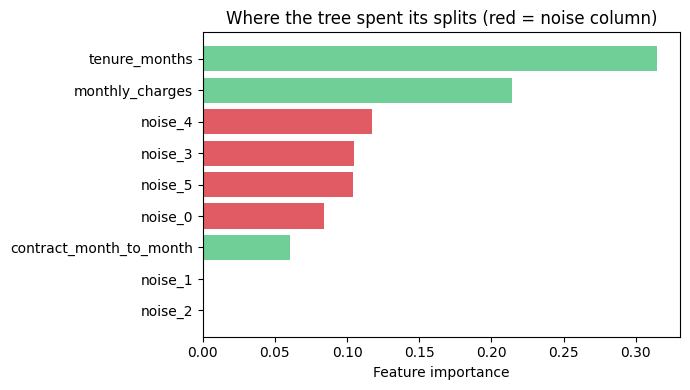

Share of total importance spent on pure noise columns: 41.0%


In [ ]:
tree_model = all_features_pipeline.named_steps["model"]
importances = pd.Series(tree_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7, 4))
colors = ["#E15B64" if name.startswith("noise") else "#6FCF97" for name in importances.index]
ax.barh(importances.index[::-1], importances.values[::-1], color=colors[::-1])
ax.set_xlabel("Feature importance")
ax.set_title("Where the tree spent its splits (red = noise column)")
plt.tight_layout(); plt.show()

noise_share = importances[[i for i in importances.index if i.startswith("noise")]].sum()
print(f"Share of total importance spent on pure noise columns: {noise_share:.1%}")


## 4. Refining the feature set — SelectKBest inside the same Pipeline

Feature selection doesn't need to be a separate manual step. `SelectKBest` slots directly into the Pipeline, automatically keeping only the strongest features every time the model is retrained.


In [ ]:
refined_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("select", SelectKBest(f_classif, k=3)),   # keep only the 3 best features
    ("model", DecisionTreeClassifier(random_state=42)),
])

refined_pipeline.fit(X_train, y_train)
pred_refined = refined_pipeline.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, pred_refined):.3f}")
print(f"F1:       {f1_score(y_test, pred_refined):.3f}")

selected_mask = refined_pipeline.named_steps["select"].get_support()
print("Features SelectKBest kept:", list(X_train.columns[selected_mask]))


Accuracy: 0.933


F1:       0.824
Features SelectKBest kept: ['tenure_months', 'monthly_charges', 'contract_month_to_month']


**Checkpoint:** this should match the slide — Accuracy ≈ 0.933, F1 ≈ 0.824, and `SelectKBest` should have kept exactly the three real columns on its own, without us telling it which ones were meaningful.


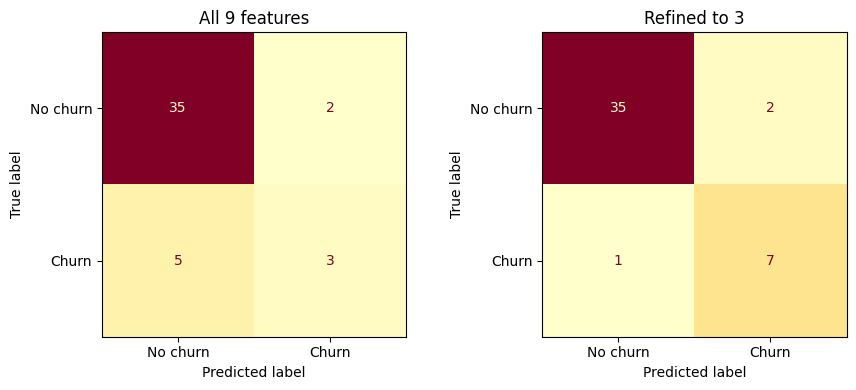

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
for ax, pred, name in zip(axes, [pred_all, pred_refined], ["All 9 features", "Refined to 3"]):
    ConfusionMatrixDisplay.from_predictions(
        y_test, pred, display_labels=["No churn", "Churn"], cmap="YlOrRd", colorbar=False, ax=ax
    )
    ax.set_title(name)
plt.tight_layout(); plt.show()


## 5. Exercises


**Exercise 1.** Change `k=3` to `k=5` in `refined_pipeline` and refit. Does F1 go up, down, or stay about the same? Print the new F1 and the features kept.


In [ ]:
# TODO



<details><summary>Solution</summary>

```python
pipeline_k5 = Pipeline([
    ("scaler", StandardScaler()),
    ("select", SelectKBest(f_classif, k=5)),
    ("model", DecisionTreeClassifier(random_state=42)),
])
pipeline_k5.fit(X_train, y_train)
pred_k5 = pipeline_k5.predict(X_test)
print(f1_score(y_test, pred_k5))
print(list(X_train.columns[pipeline_k5.named_steps["select"].get_support()]))
```
With `k=5`, two noise columns get let back in alongside the three real features, and F1 typically drops back toward (or below) the `k=3` result — more features than the useful signal actually contains rarely helps.
</details>


**Exercise 2.** Without running code, explain in one or two sentences why calling `.fit()` on a `Pipeline` with `X_train` only (not the full dataset) matters for the `StandardScaler` step specifically.


<details><summary>Solution</summary>

If the scaler were fit on the full dataset (train + test combined), its mean and standard deviation would be influenced by test-set values — meaning information about the test set has leaked into a transformation applied before training. Fitting only on `X_train` keeps the test set genuinely unseen until prediction time.
</details>


**Exercise 3.** `SelectKBest` picked 3 features on its own. Confirm they're the same 3 columns used in the slide's "refined" example, by comparing `selected_mask` against `["tenure_months", "monthly_charges", "contract_month_to_month"]`.


In [ ]:
# TODO



<details><summary>Solution</summary>

```python
kept = set(X_train.columns[selected_mask])
expected = {"tenure_months", "monthly_charges", "contract_month_to_month"}
print(kept == expected)
```
</details>


## 6. Recap

- A **Pipeline** automates a supervised workflow into one `.fit()`/`.predict()` call, and fitting it only on training data automatically prevents test-set leakage.
- **Irrelevant features actively hurt** models like decision trees, which will split on noise as readily as on real signal — our tree spent nearly half its total importance on 6 columns that carried no real information.
- **`SelectKBest`** (or any feature-selection step) slots directly into a Pipeline, making feature refinement itself part of the automated workflow rather than a manual, easy-to-forget step.
